In [13]:
sales_etl.to_csv("sales_etl_clean.csv", index=False)
monthly_dataset.to_csv("monthly_dataset.csv", index=False)
dqc_report.to_csv("dqc_report.csv", index=False)

print("Files saved")

Files saved


In [12]:
monthly_dataset = (
    sales_etl.groupby(
        ["date_block_num", "shop_id", "item_id", "item_category_id", "year", "month"],
        as_index=False
    )
    .agg(
        item_cnt_month=("item_cnt_day", "sum"),
        avg_item_price=("item_price", "mean"),
        total_revenue=("revenue", "sum")
    )
)

monthly_dataset["item_cnt_month"] = monthly_dataset["item_cnt_month"].clip(0, 20)

print(monthly_dataset.shape)
display(monthly_dataset.head())

(1608224, 9)


,date_block_num,shop_id,item_id,item_category_id,year,month,item_cnt_month,avg_item_price,total_revenue
0,0,0,32,40,2013,1,6.0,221.0,1326.0
1,0,0,33,37,2013,1,3.0,347.0,1041.0
2,0,0,35,40,2013,1,1.0,247.0,247.0
3,0,0,43,40,2013,1,1.0,221.0,221.0
4,0,0,51,57,2013,1,2.0,128.5,257.0


In [11]:
sales_etl = sales.copy()

sales_etl = sales_etl.drop_duplicates()
sales_etl = sales_etl[(sales_etl["item_price"] > 0) & (sales_etl["item_price"] < 100000)]
sales_etl = sales_etl[(sales_etl["item_cnt_day"] > 0) & (sales_etl["item_cnt_day"] < 1000)]

sales_etl = sales_etl.merge(items, on="item_id", how="left")
sales_etl = sales_etl.merge(item_categories, on="item_category_id", how="left")
sales_etl = sales_etl.merge(shops, on="shop_id", how="left")

sales_etl["revenue"] = sales_etl["item_price"] * sales_etl["item_cnt_day"]

print(sales_etl.shape)
display(sales_etl.head())

(2928483, 14)


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,day,revenue,item_name,item_category_id,item_category_name,shop_name
0,2013-01-02,0,59,22154,999.00,1.0,2013,1,2,999.00,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,2013-01-03,0,25,2552,899.00,1.0,2013,1,3,899.00,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,2013-01-06,0,25,2554,1709.05,1.0,2013,1,6,1709.05,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,2013-01-15,0,25,2555,1099.00,1.0,2013,1,15,1099.00,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""
4,2013-01-10,0,25,2564,349.00,1.0,2013,1,10,349.00,DEEP PURPLE Perihelion: Live In Concert DVD (К...,59,Музыка - Музыкальное видео,"Москва ТРК ""Атриум"""


In [10]:
dqc_report = pd.DataFrame({
    "check_name": [
        "missing_values_sales",
        "duplicate_rows_sales",
        "negative_or_zero_price",
        "negative_or_zero_item_cnt_day",
        "too_large_price_>=100000",
        "too_large_item_cnt_day_>=1000"
    ],
    "issue_count": [
        int(sales.isnull().sum().sum()),
        int(sales.duplicated().sum()),
        int((sales["item_price"] <= 0).sum()),
        int((sales["item_cnt_day"] <= 0).sum()),
        int((sales["item_price"] >= 100000).sum()),
        int((sales["item_cnt_day"] >= 1000).sum())
    ]
})

display(dqc_report)

,check_name,issue_count
0,missing_values_sales,0
1,duplicate_rows_sales,6
2,negative_or_zero_price,1
3,negative_or_zero_item_cnt_day,7356
4,too_large_price_>=100000,1
5,too_large_item_cnt_day_>=1000,2


In [9]:
sales["revenue"] = sales["item_price"] * sales["item_cnt_day"]

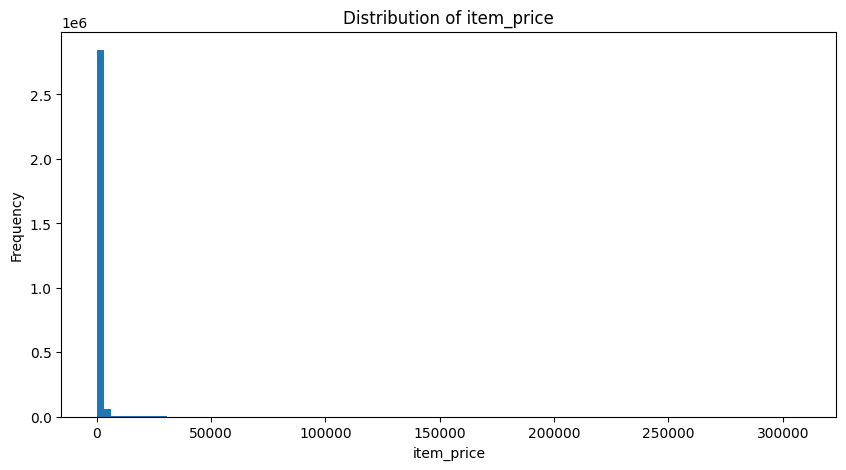

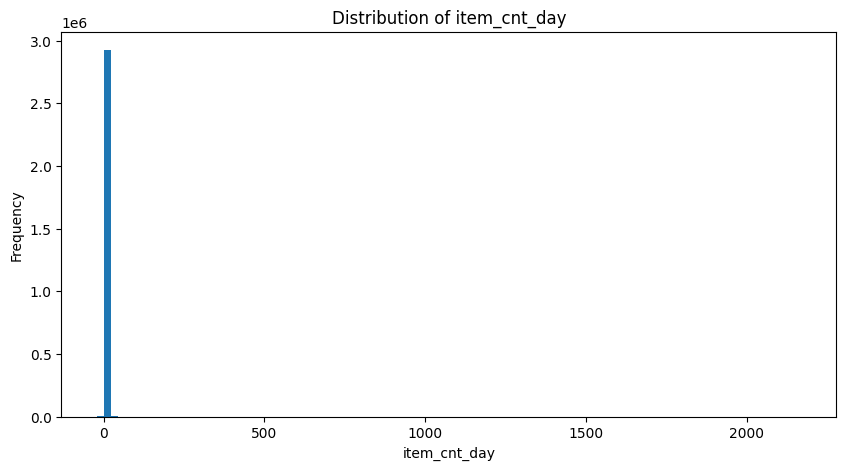

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(sales["item_price"], bins=100)
plt.title("Distribution of item_price")
plt.xlabel("item_price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(sales["item_cnt_day"], bins=100)
plt.title("Distribution of item_cnt_day")
plt.xlabel("item_cnt_day")
plt.ylabel("Frequency")
plt.show()

In [7]:
print("Duplicates in sales:", sales.duplicated().sum())
print("Rows with item_price <= 0:", (sales["item_price"] <= 0).sum())
print("Rows with item_cnt_day <= 0:", (sales["item_cnt_day"] <= 0).sum())
print("Rows with item_price >= 100000:", (sales["item_price"] >= 100000).sum())
print("Rows with item_cnt_day >= 1000:", (sales["item_cnt_day"] >= 1000).sum())

Duplicates in sales: 6
Rows with item_price <= 0: 1
Rows with item_cnt_day <= 0: 7356
Rows with item_price >= 100000: 1
Rows with item_cnt_day >= 1000: 2


In [6]:
sales["date"] = pd.to_datetime(sales["date"], format="%d.%m.%Y")
sales["year"] = sales["date"].dt.year
sales["month"] = sales["date"].dt.month
sales["day"] = sales["date"].dt.day

display(sales[["date", "year", "month", "day"]].head())

,date,year,month,day
0,2013-01-02,2013,1,2
1,2013-01-03,2013,1,3
2,2013-01-05,2013,1,5
3,2013-01-06,2013,1,6
4,2013-01-15,2013,1,15


In [5]:
datasets = {
    "sales": sales,
    "items": items,
    "item_categories": item_categories,
    "shops": shops,
    "test": test,
    "sample_submission": sample_submission
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"DATASET: {name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.dtypes)
    print(df.isnull().sum())
    print()

DATASET: sales
Shape: (2935849, 6)
Columns: ['date', 'date_block_num', 'shop_id', 'item_id', 'item_price', 'item_cnt_day']
date                  str
date_block_num      int64
shop_id             int64
item_id             int64
item_price        float64
item_cnt_day      float64
dtype: object
date              0
date_block_num    0
shop_id           0
item_id           0
item_price        0
item_cnt_day      0
dtype: int64

DATASET: items
Shape: (22170, 3)
Columns: ['item_name', 'item_id', 'item_category_id']
item_name             str
item_id             int64
item_category_id    int64
dtype: object
item_name           0
item_id             0
item_category_id    0
dtype: int64

DATASET: item_categories
Shape: (84, 2)
Columns: ['item_category_name', 'item_category_id']
item_category_name      str
item_category_id      int64
dtype: object
item_category_name    0
item_category_id      0
dtype: int64

DATASET: shops
Shape: (60, 2)
Columns: ['shop_name', 'shop_id']
shop_name      str
shop_id

In [4]:
display(sales.head())
display(items.head())
display(item_categories.head())
display(shops.head())
display(test.head())

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [3]:
sales = pd.read_csv("sales_train.csv")
items = pd.read_csv("items.csv")
item_categories = pd.read_csv("item_categories.csv")
shops = pd.read_csv("shops.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("sales:", sales.shape)
print("items:", items.shape)
print("item_categories:", item_categories.shape)
print("shops:", shops.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)

sales: (2935849, 6)
items: (22170, 3)
item_categories: (84, 2)
shops: (60, 2)
test: (214200, 3)
sample_submission: (214200, 2)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.
